# libraries import

In [2]:
import keras
keras.utils.set_random_seed(3342)

import matplotlib.pyplot as plt
#from google.colab import files

import h5py
import numpy as np
import seaborn as sns
import os

# plotting functions

In [3]:
# weights heatmap
def plot_weight_heatmap(weights_array, title):
    if not isinstance(weights_array, np.ndarray): return
    plot_data = weights_array
    ylabel = "Input / Characteristic"; xlabel = "Output / Neuron"
    if weights_array.ndim == 1:
        plot_data = weights_array.reshape(1, -1); ylabel = "Bias"
    elif weights_array.ndim > 2:
        print(f"Error for '{title}': array has {weights_array.ndim} dimensions.")
        return
    fig_height = np.clip(plot_data.shape[0] * 0.4, 6, 20)
    fig_width = np.clip(plot_data.shape[1] * 0.4, 8, 24)
    plt.figure(figsize=(fig_width, fig_height))
    show_annotations = (plot_data.size < 500)
    sns.heatmap(plot_data, annot=show_annotations, fmt=".2f", cmap="vlag", center=0)
    plt.title(f"Heatmap: {title}\nShape: {weights_array.shape} mean: {np.mean(weights_array)}", fontsize=16)
    plt.xlabel(xlabel, fontsize=12); plt.ylabel(ylabel, fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='validation loss')
    plt.grid(True)

    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.title(title)

    plt.legend(['train', 'validation'], loc='upper right')
    plt.tight_layout()

    #plt.savefig(f"{title}.png")
    #files.download(f"{title}.png")

    plt.show()

In [ ]:
def plot_accuracy(history, title):
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='validation accuracy')
    plt.grid(True)

    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.title(title)

    plt.legend(['train', 'validation'], loc='lower right')
    plt.tight_layout()

    #plt.savefig(f"{title}.png")
    #files.download(f"{title}.png")

    plt.show()

# Dataset import & normalization


In [ ]:
# data loading
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# image shape
height = x_train[0].shape[0]
width = x_train[0].shape[1]

print()
print(f"image shape = {height}x{width}")


image shape = 28x28


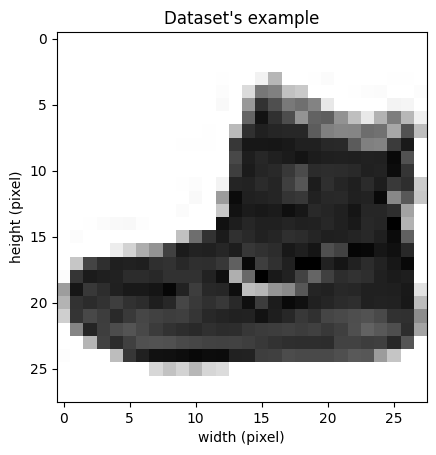

In [ ]:
# image visualization
plt.figure()
plt.imshow(x_train[0], cmap=plt.cm.binary)

plt.title(f"Dataset's example")
plt.xlabel("width (pixel)")
plt.ylabel("height (pixel)")
plt.show()

In [ ]:
# data normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# target encoding
y_train_categorical = keras.utils.to_categorical(y_train, num_classes=10)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
# data flattening
x_train = x_train.reshape(x_train.shape[0], height * width)
x_test = x_test.reshape(x_test.shape[0], height * width)

# First model creation

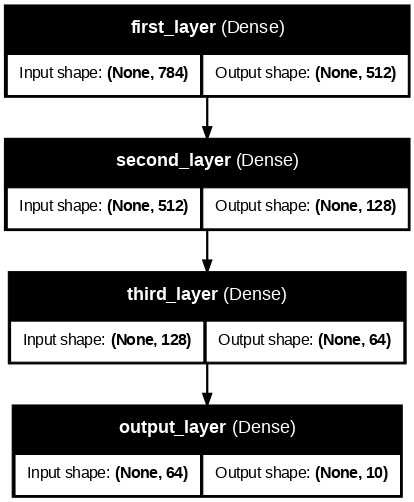

In [ ]:
first_model = keras.Sequential(
    [
        keras.Input(shape=(784,)),
        keras.layers.Dense(512, activation="relu", name='first_layer'),
        keras.layers.Dense(128, activation='relu', name='second_layer'),
        keras.layers.Dense(64, activation='relu', name='third_layer'),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

first_model.build()

first_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(first_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
first_model_history = first_model.fit(x_train, y_train_categorical, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.4649 - loss: 43.9580 - val_accuracy: 0.7077 - val_loss: 0.7860
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7288 - loss: 0.7233 - val_accuracy: 0.7580 - val_loss: 0.6580
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7585 - loss: 0.6865 - val_accuracy: 0.7920 - val_loss: 0.6185
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7769 - loss: 0.6437 - val_accuracy: 0.7433 - val_loss: 0.6902
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7740 - loss: 0.6512 - val_accuracy: 0.6665 - val_loss: 0.8646
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7197 - loss: 0.7630 - val_accuracy: 0.4488 - val_loss: 2.0093
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3758 - loss: 1.5292 - val_accuracy: 0.1996 - val_loss: 1.7371
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.2029 - loss: 1.7438 - val_a

## first model training results

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

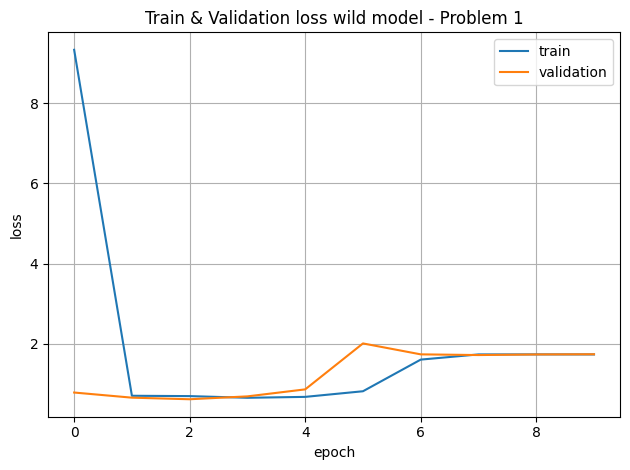

In [ ]:
plot_loss(first_model_history, "Train & Validation loss wild model - Problem 1")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

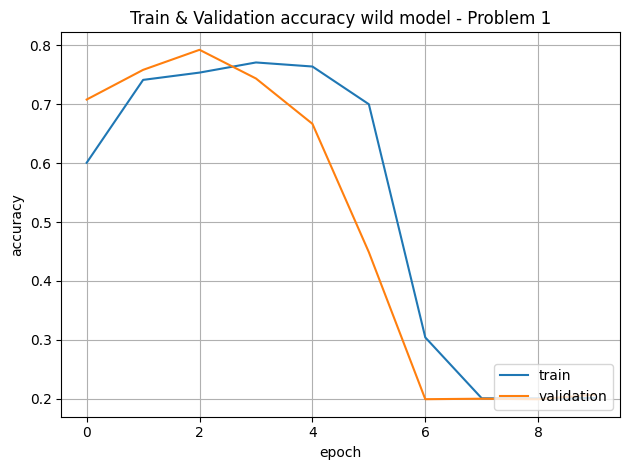

In [ ]:
plot_accuracy(first_model_history, "Train & Validation accuracy wild model - Problem 1")

## weight plot


--- heatmaps generation ---


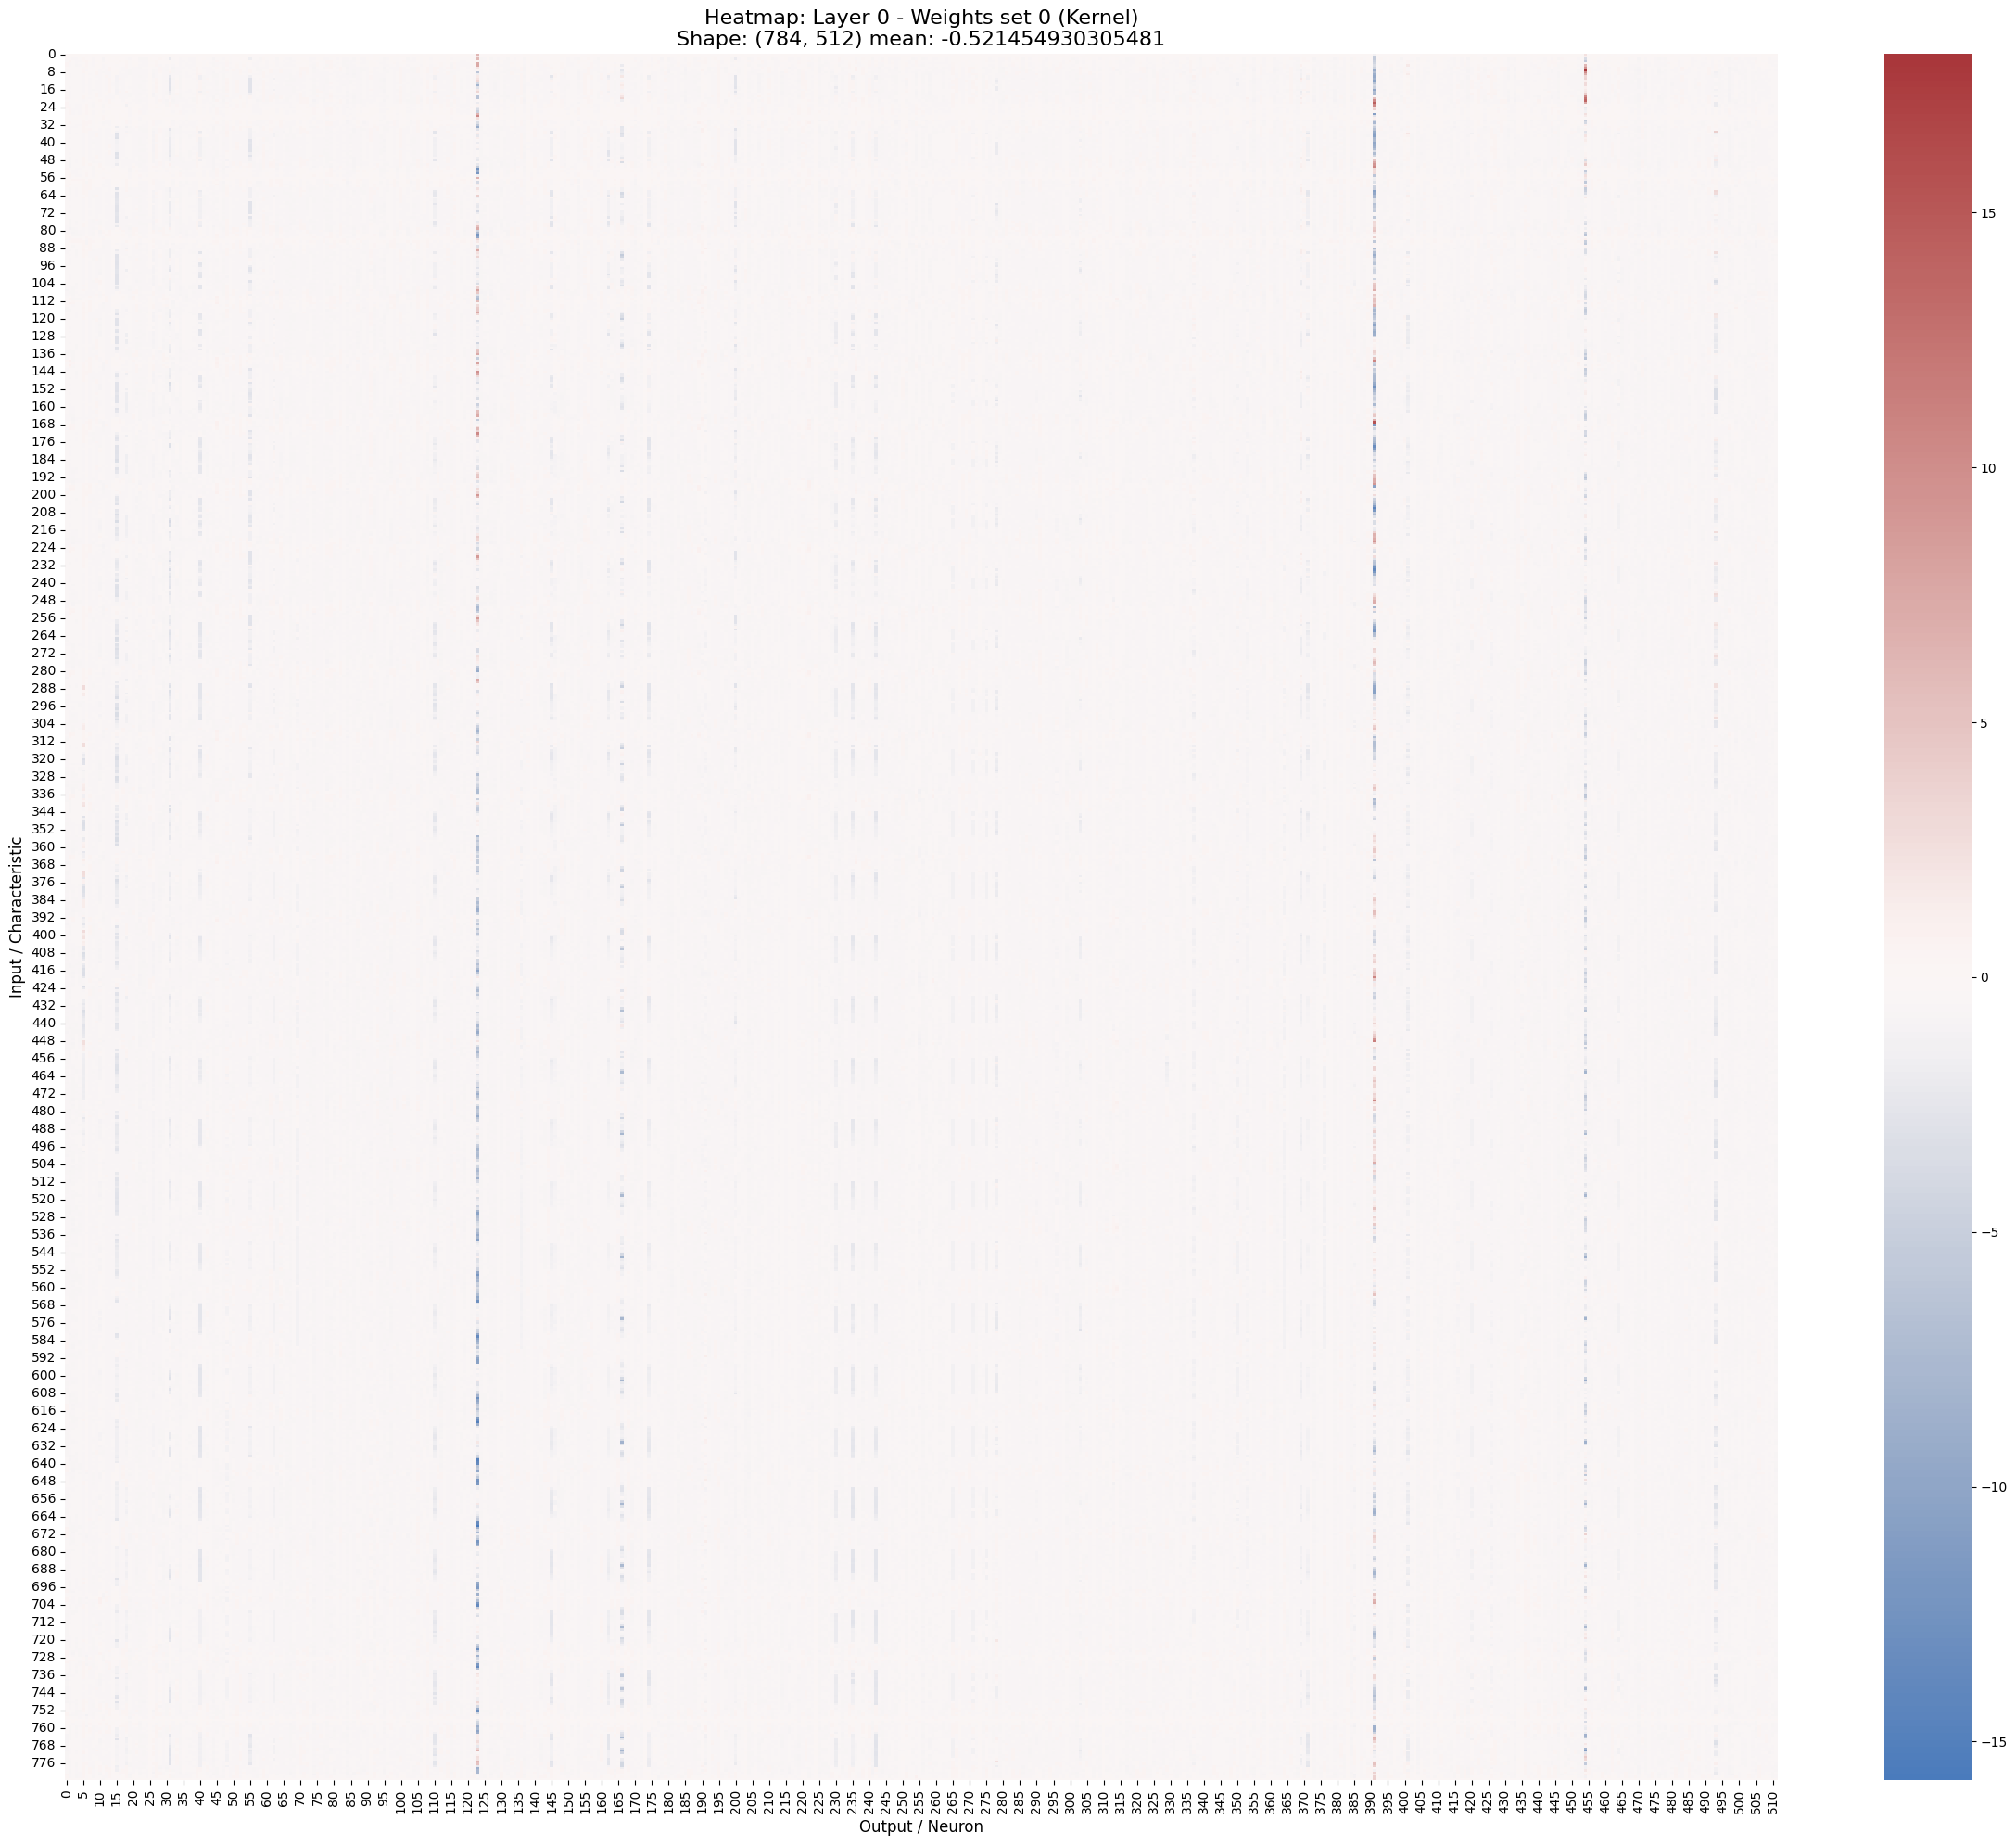

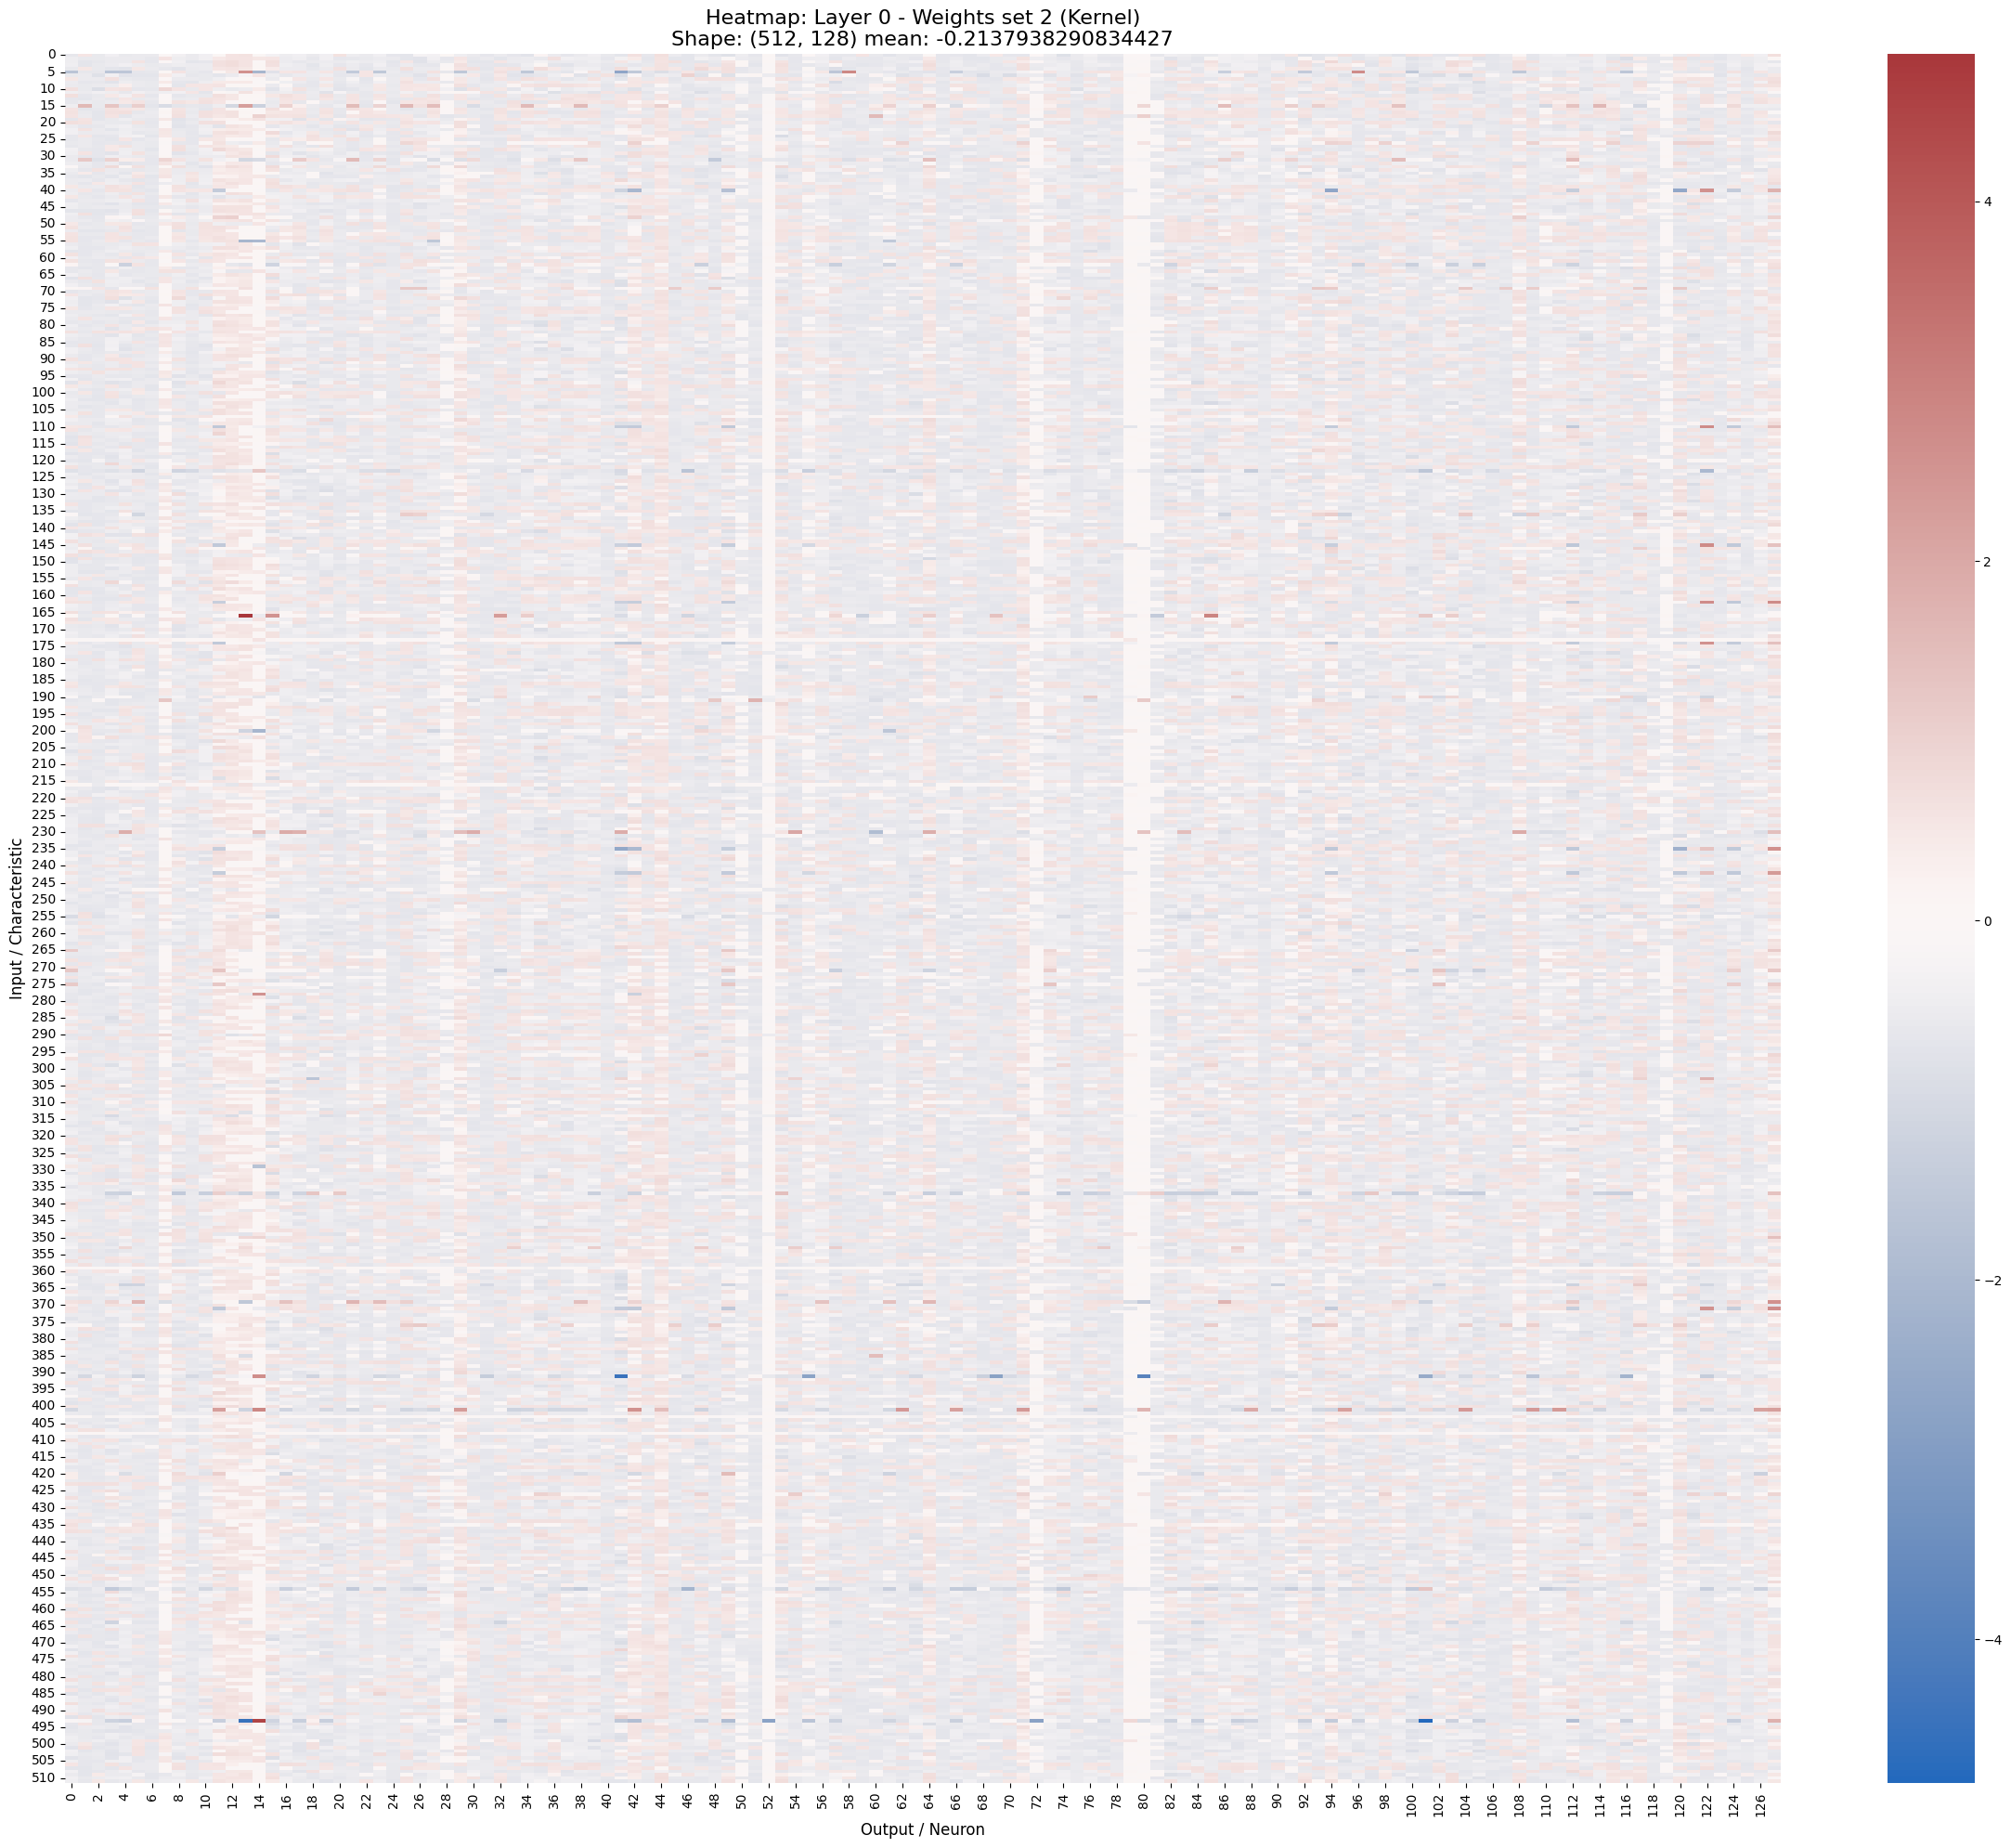

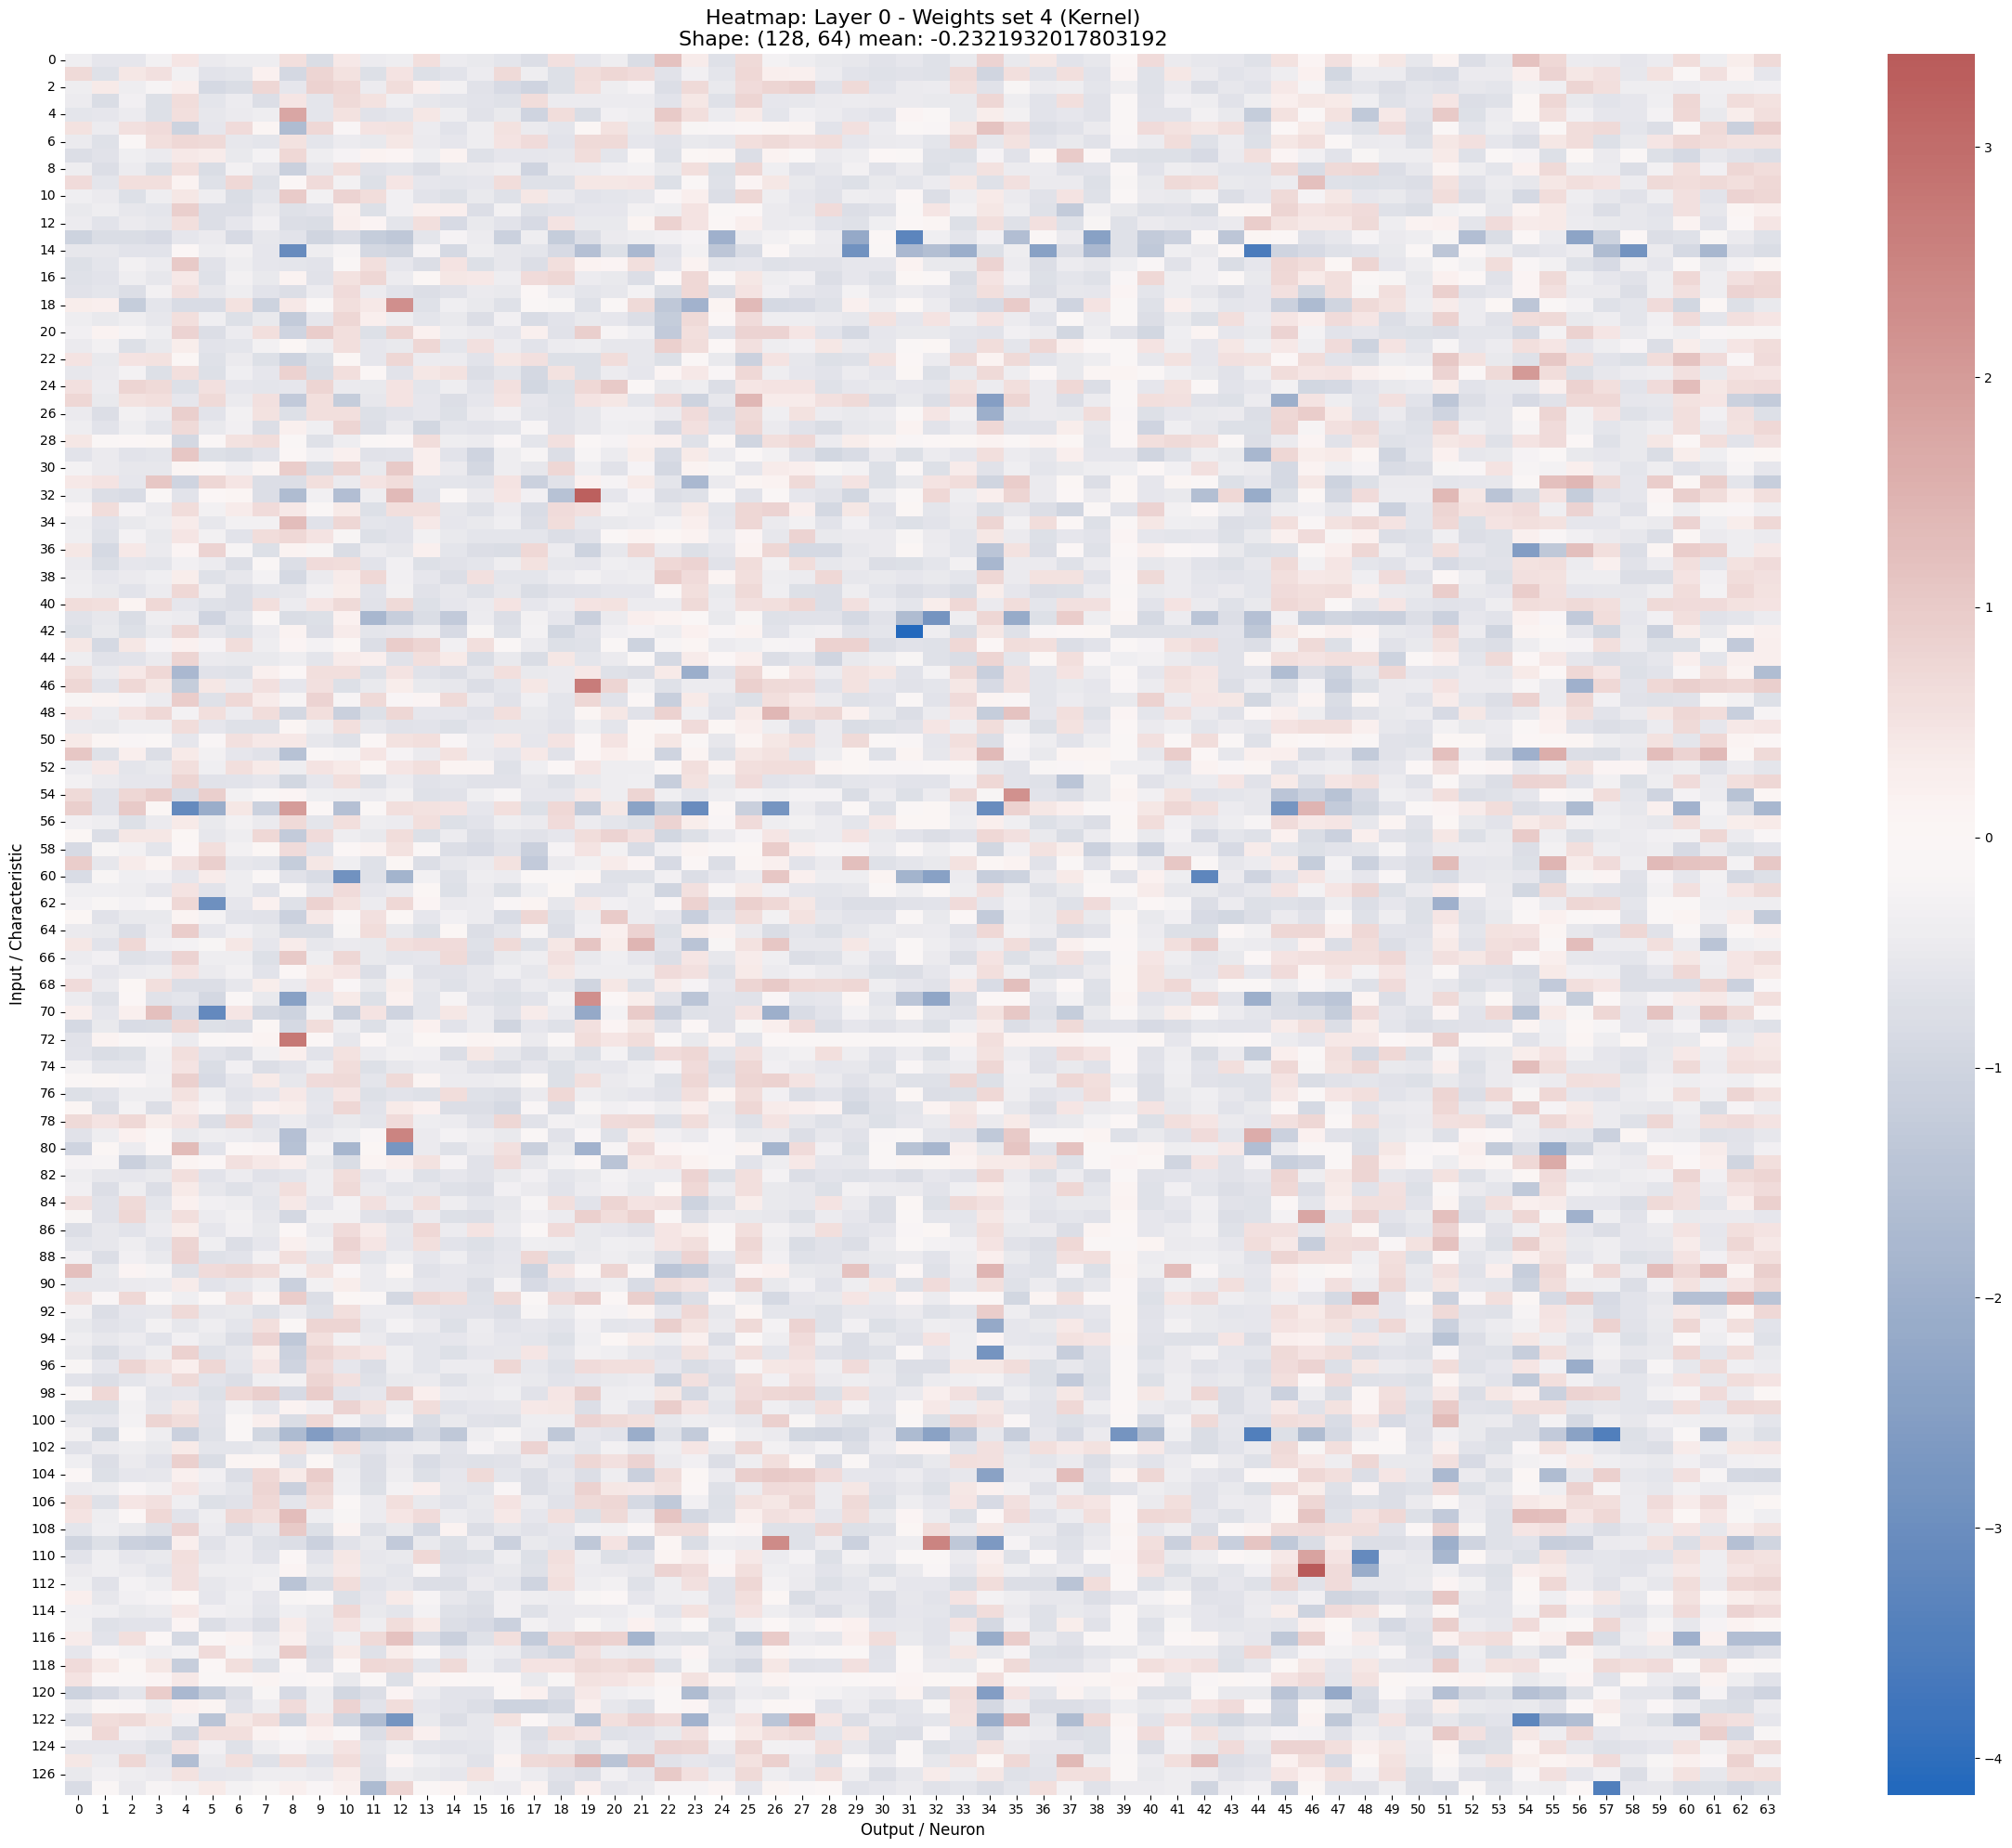

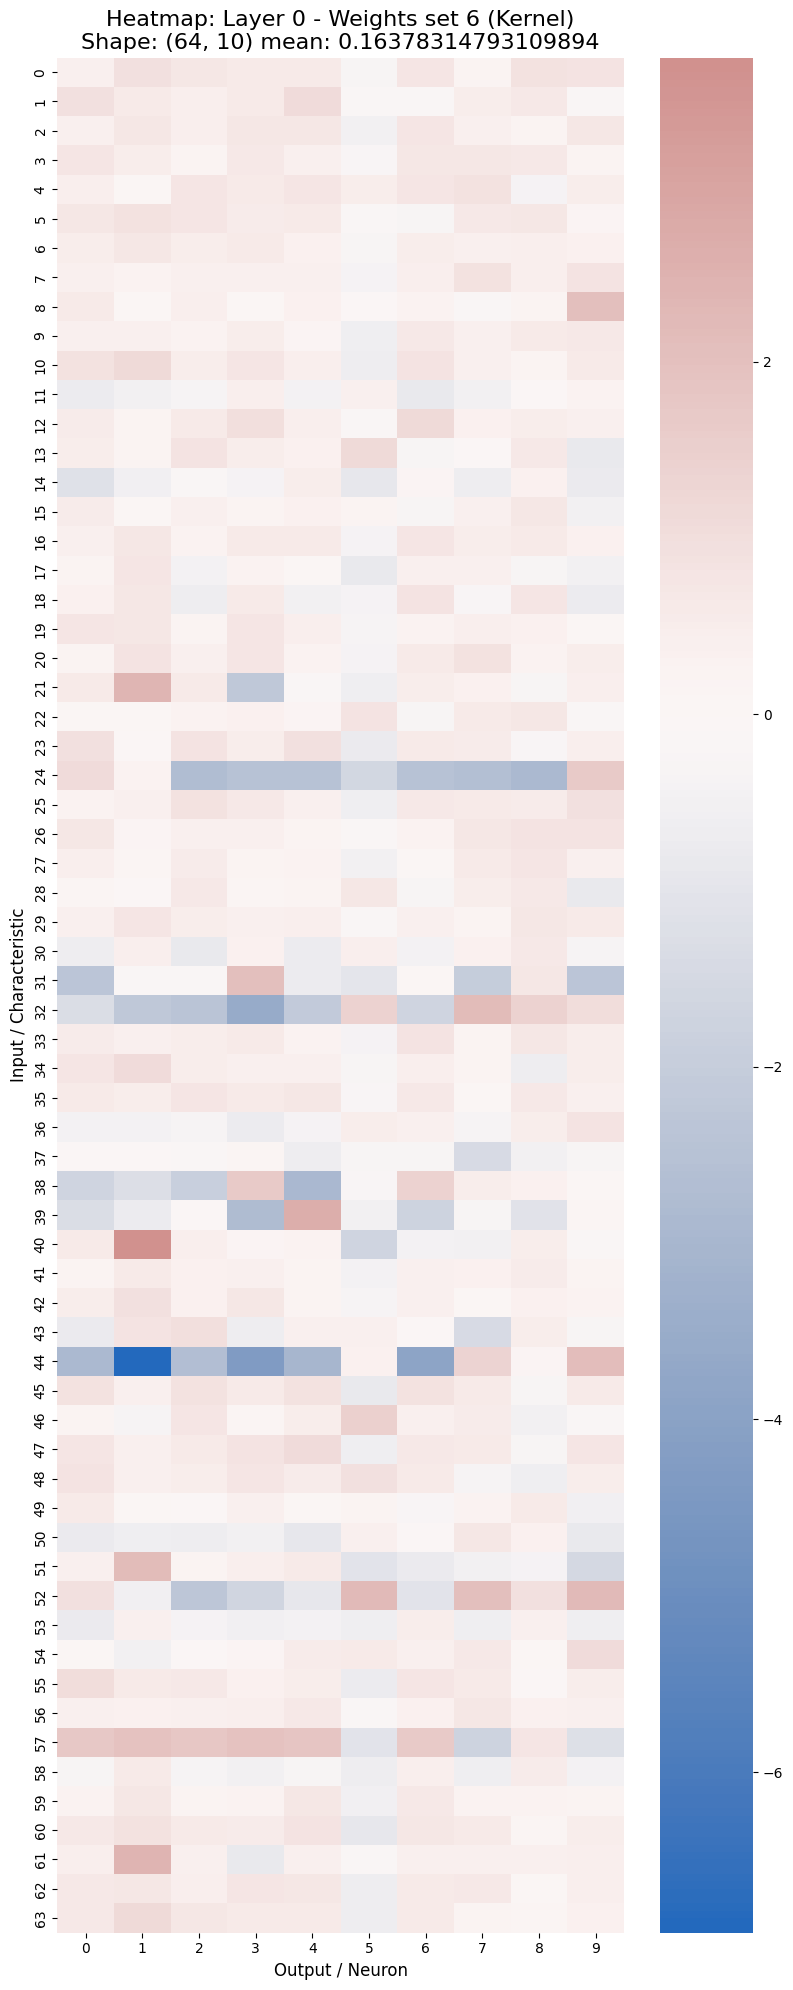


Completed.


In [4]:
# extract all_layers_weights' from weights.h5)
filename = 'problem_one.weights.h5'
all_layers_weights = []
try:
    with h5py.File(filename, 'r') as f:
        layer_group_names = list(f.keys())
        for layer_name in layer_group_names:
            if 'optimizer' in layer_name.lower() or 'vars' in layer_name.lower():
                continue
            layer_group = f[layer_name]
            current_layer_weights = []
            def collect_datasets_from_group(name, obj):
                if isinstance(obj, h5py.Dataset):
                    weights_array = np.array(obj)
                    current_layer_weights.append(weights_array)
            if isinstance(layer_group, h5py.Group):
                layer_group.visititems(collect_datasets_from_group)
            if current_layer_weights:
                all_layers_weights.append(current_layer_weights)
except IOError:
    print(f"Error: File '{filename}' not found.")
except Exception as e:
    print(f"Error: {e}")


# show all heatmap of each layer without plotting bias heatmap
if all_layers_weights:
    print("\n--- heatmaps generation ---")

    for i in range(len(all_layers_weights)):
        layer_weights_list = all_layers_weights[i]

        for j, weights in enumerate(layer_weights_list):

            # bias filter
            if weights.ndim == 1:
                continue

            # plot info update
            plot_title = f"Layer {i} - Weights set {j} (Kernel)"

            plot_weight_heatmap(
                weights_array=weights,
                title=plot_title,
            )

else:
    print("\n'all_layers_weights' is empty no heatmaps generation")

print("\nCompleted.")

# first improved model

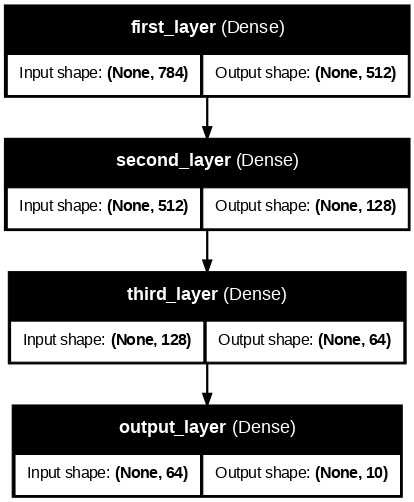

In [ ]:
second_model = keras.Sequential(
    [
        keras.Input(shape=(784,)),
        keras.layers.Dense(512, activation="relu", name='first_layer'),
        keras.layers.Dense(128, activation='relu', name='second_layer'),
        keras.layers.Dense(64, activation='relu', name='third_layer'),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

second_model.build()

second_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(first_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
second_model_history = second_model.fit(x_train, y_train_categorical, epochs=50, batch_size=128, validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7544 - loss: 0.7010 - val_accuracy: 0.8577 - val_loss: 0.4013
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8602 - loss: 0.3819 - val_accuracy: 0.8676 - val_loss: 0.3696
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8753 - loss: 0.3373 - val_accuracy: 0.8705 - val_loss: 0.3616
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8846 - loss: 0.3091 - val_accuracy: 0.8771 - val_loss: 0.3484
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8935 - loss: 0.2876 - val_accuracy: 0.8765 - val_loss: 0.3434
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8982 - loss: 0.2718 - val_accuracy: 0.8806 - val_loss: 0.3394
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9036 - loss: 0.2564 - val_accuracy: 0.8824 - val_loss: 0.3401
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9072 - loss: 0.2461 - val_accu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

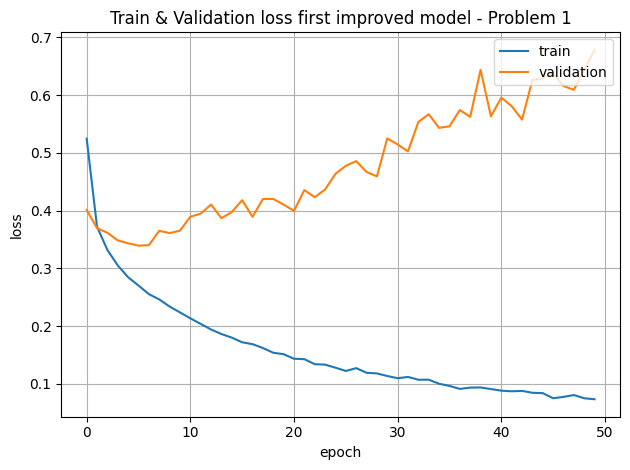

In [ ]:
plot_loss(second_model_history, "Train & Validation loss first improved model - Problem 1")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

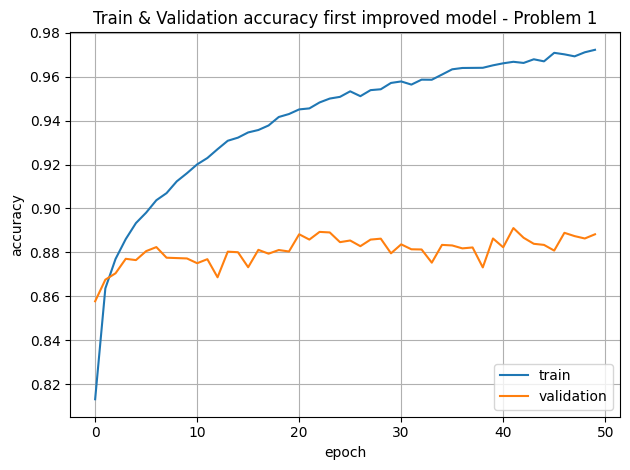

In [ ]:
plot_accuracy(second_model_history, "Train & Validation accuracy first improved model - Problem 1")

# second improved model

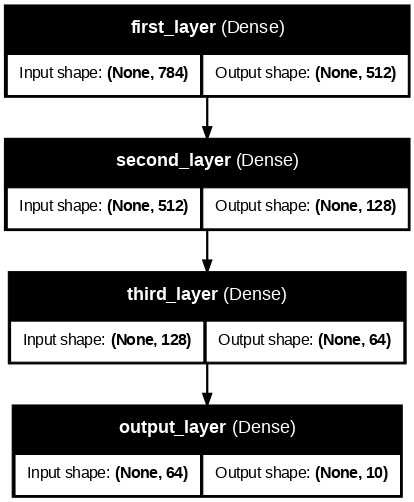

In [ ]:
third_model = keras.Sequential(
    [
        keras.Input(shape=(784,)),
        keras.layers.Dropout(0.25),
        keras.layers.Dense(512, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(128, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(64, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

third_model.build()

third_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(first_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, min_delta=0.02)
third_model_history = third_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3945 - loss: 9.4181 - val_accuracy: 0.7241 - val_loss: 5.3108
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6977 - loss: 4.7999 - val_accuracy: 0.7738 - val_loss: 3.1688
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7393 - loss: 2.9938 - val_accuracy: 0.7975 - val_loss: 2.1614
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7656 - loss: 2.1086 - val_accuracy: 0.8110 - val_loss: 1.6294
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7736 - loss: 1.6389 - val_accuracy: 0.8108 - val_loss: 1.3312
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.7786 - loss: 1.3692 - val_accuracy: 0.8135 - val_loss: 1.1508
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7843 - loss: 1.2043 - val_accuracy: 0.8117 - val_loss: 1.0428
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7879 - loss: 1.097

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

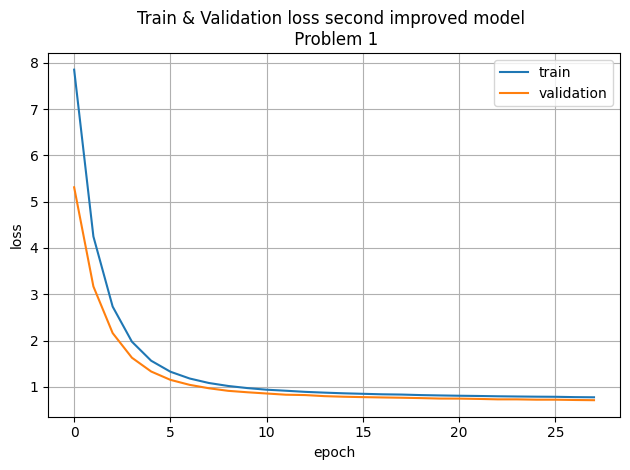

In [ ]:
plot_loss(third_model_history, "Train & Validation loss second improved model \n Problem 1")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

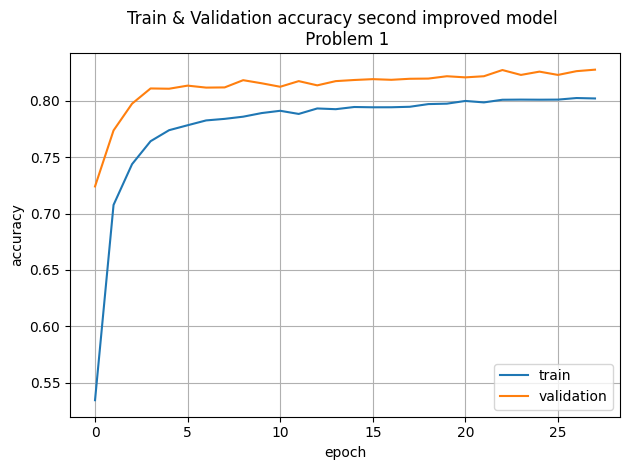

In [ ]:
plot_accuracy(third_model_history, "Train & Validation accuracy second improved model \n Problem 1")

# third improved model

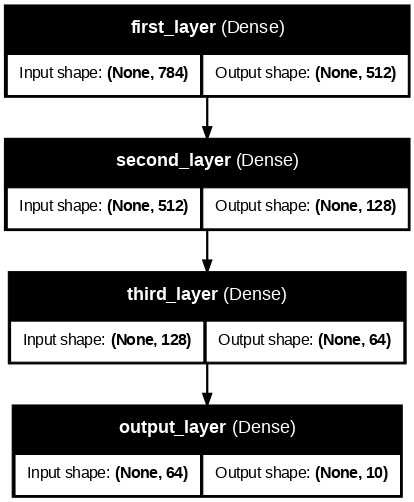

In [ ]:
fourth_model = keras.Sequential(
    [
        keras.Input(shape=(784,)),
        keras.layers.Dropout(0.25),
        keras.layers.Dense(512, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(128, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(64, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

fourth_model.build()

fourth_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(first_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, min_delta=0.02)
fourth_model_history = fourth_model.fit(x_train, y_train_categorical, epochs=100, batch_size=256, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4769 - loss: 9.8375 - val_accuracy: 0.7753 - val_loss: 6.5215
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7748 - loss: 5.9363 - val_accuracy: 0.8083 - val_loss: 4.3812
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8046 - loss: 4.0498 - val_accuracy: 0.8163 - val_loss: 3.1513
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8122 - loss: 2.9622 - val_accuracy: 0.8218 - val_loss: 2.4178
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8153 - loss: 2.3088 - val_accuracy: 0.8233 - val_loss: 1.9666
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8180 - loss: 1.9000 - val_accuracy: 0.8253 - val_loss: 1.6723
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8204 - loss: 1.6345 - val_accuracy: 0.8245 - val_loss: 1.4785
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8216 - loss: 1.4554 - 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

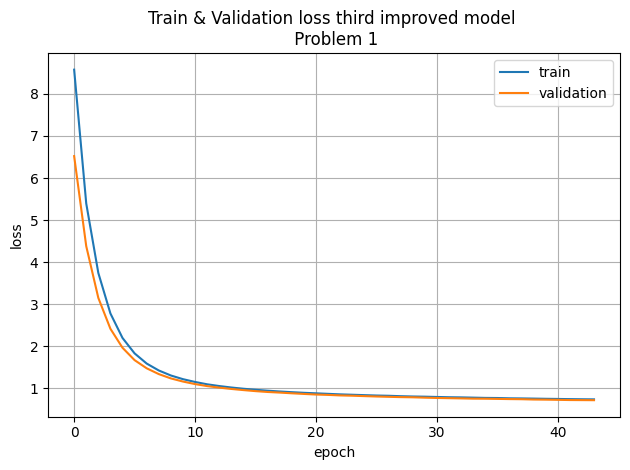

In [ ]:
plot_loss(fourth_model_history, "Train & Validation loss third improved model \n Problem 1")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

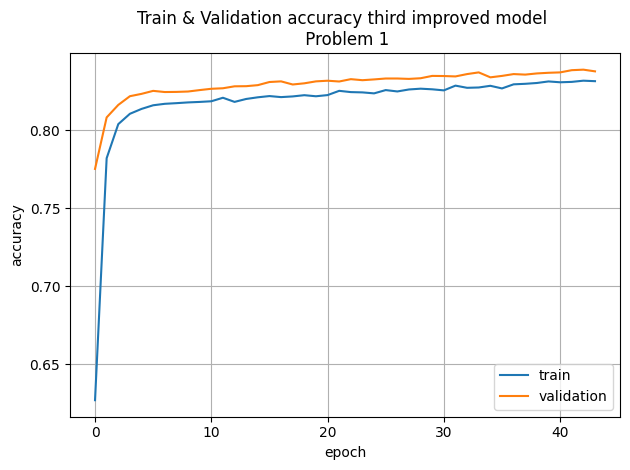

In [ ]:
plot_accuracy(fourth_model_history, "Train & Validation accuracy third improved model \n Problem 1")